# Transition State Optimizations

<div>
<img src="SN2.png" width="200"/>
</div>

In [46]:
from ase import Atoms
from ase.io import read
from ase.visualize import view
from ase.optimize import BFGS
import numpy as np

'''
C        0.00000000       0.00000000       0.00000000
Cl       1.78400000       0.00000000       0.00000000
H       -0.34400000       1.02900000      -0.00000000
H       -0.34400000      -0.51500000      -0.89100000
H       -0.34400000      -0.51500000       0.89100000
Br      -3.00000000       0.00000000       0.00000000
'''


molecule = read('sn2_initial_structure.xyz')
view(molecule, viewer='x3d')  # Visualize the molecule after reading it from the file

In [47]:
# We need to get an initial guess for a transition state structure.
#  This can be done by manipulating the positions of the atoms in the molecule.
#  For example, we can move the nucleophile closer to the carbon atom that is being attacked.
from aimnet.calculators import AIMNet2ASE
calculator = AIMNet2ASE(
    'aimnet2-2025',  # Specify the AIMNet model to use
    charge = 0  # Specify the charge of the molecule
)

# Br - C - Cl is currently aligned along x.  We want to fix these atoms atoms along this line
#  We will also fix the position of the carbon entirely
#  Carbon index = 0
#  Chlorine index = 1
#  Bromine index = 5
from ase.constraints import FixedLine, FixAtoms, FixInternals
cbr_bond_indices = [0,5]
cbr_constraint = FixInternals(bonds=[3.0, *cbr_bond_indices])
molecule.set_constraint(cbr_constraint)


In [48]:
# Attach calculator and move Br closer to C iteratively
molecule.calc = calculator

res = []
for cbr_distance in np.linspace(3.0, 1.7, 14):
    # Reduce the C-Br distance by 0.1 Å in each step
    molecule.set_distance(0, 5, cbr_distance, fix=0)
    molecule.set_constraint()
    constraint = FixAtoms(indices=[0, 5])
    molecule.set_constraint(constraint)
    dyn = BFGS(molecule)
    dyn.run(fmax=0.01)
    res.append((molecule.get_distance(0, 5), molecule.get_potential_energy(), molecule.copy()))





      Step     Time          Energy          fmax
BFGS:    0 12:47:35   -83676.893681        0.861939
BFGS:    1 12:47:35   -83676.903626        0.590973
BFGS:    2 12:47:35   -83676.912470        0.076835
BFGS:    3 12:47:35   -83676.912680        0.044200
BFGS:    4 12:47:35   -83676.912837        0.038916
BFGS:    5 12:47:35   -83676.912979        0.039634
BFGS:    6 12:47:35   -83676.913147        0.040702
BFGS:    7 12:47:35   -83676.913260        0.028466
BFGS:    8 12:47:35   -83676.913291        0.009618
      Step     Time          Energy          fmax
BFGS:    0 12:47:35   -83676.900696        0.085238
BFGS:    1 12:47:35   -83676.900975        0.047292
BFGS:    2 12:47:35   -83676.901169        0.030058
BFGS:    3 12:47:35   -83676.901229        0.033809
BFGS:    4 12:47:35   -83676.901452        0.034784
BFGS:    5 12:47:35   -83676.901532        0.025290
BFGS:    6 12:47:35   -83676.901561        0.020039
BFGS:    7 12:47:35   -83676.901568        0.010964
BFGS:    8 12:47

In [49]:
print([r[0] for r in res])

[np.float64(3.0), np.float64(2.9), np.float64(2.8), np.float64(2.7), np.float64(2.6), np.float64(2.5), np.float64(2.4), np.float64(2.3), np.float64(2.2), np.float64(2.1), np.float64(2.0), np.float64(1.9), np.float64(1.7999999999999998), np.float64(1.7)]


In [50]:
view([r[2] for r in res])

<Popen: returncode: None args: ['/home/nchopper/anaconda3/envs/aimnet2/bin/p...>

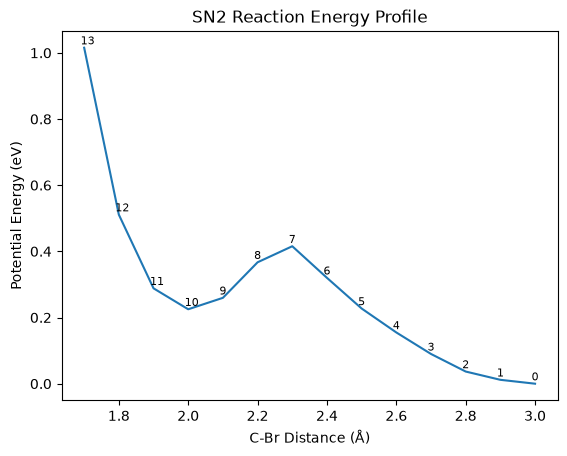

In [51]:
import matplotlib.pyplot as plt
distances = [r[0] for r in res]
energies = [r[1] - res[0][1] for r in res]
plt.plot(distances, energies)
plt.xlabel('C-Br Distance (Å)')
plt.ylabel('Potential Energy (eV)')
plt.title('SN2 Reaction Energy Profile')
# plt.show()

for i,r in enumerate(res):
    plt.text(distances[i]-0.01, energies[i]+0.01, f'{i}', fontsize=8)

In [52]:
def get_ts_index(energies):
    # If i-1 < i < i+1, then i is a local maximum
    for i in range(1, len(energies)-1):
        if energies[i-1] < energies[i] and energies[i] > energies[i+1]:
            return i
    return None

ts_guess = res[get_ts_index(energies)]
ts_guess_structure = ts_guess[2]


## TS optimization using Sella
(https://github.com/zadorlab/sella)

In [53]:
from sella import Sella
ts_guess_structure.set_constraint()
ts_guess_structure.calc = calculator
opt = Sella(ts_guess_structure, internal=True)
opt.run(1e-4, 1000)

     Step     Time          Energy         fmax         cmax       rtrust          rho
Sella   0 12:47:37   -83676.497827       0.8593       0.0000       0.1000       1.0000
Sella   1 12:47:38   -83676.484160       0.8593       0.0000       0.1000       1.0372
Sella   2 12:47:38   -83676.453858       0.8444       0.0000       0.1000       0.9563
Sella   3 12:47:38   -83676.439802       0.6561       0.0000       0.1000       0.5453
Sella   4 12:47:39   -83676.443962       0.4956       0.0000       0.1000       0.3931
Sella   5 12:47:39   -83676.450163       0.1903       0.0000       0.1000       0.8851
Sella   6 12:47:39   -83676.450251       0.2142       0.0000       0.0264      -0.0414
Sella   7 12:47:39   -83676.449102       0.1935       0.0000       0.0264       0.9263
Sella   8 12:47:39   -83676.449107       0.0152       0.0000       0.0264       1.5792
Sella   9 12:47:39   -83676.449113       0.0086       0.0000       0.0264       1.5864
Sella  10 12:47:40   -83676.449115       0.

np.True_

In [54]:
ts_guess_structure.get_potential_energy(), res[get_ts_index(energies)][1]

(-83676.44911477956, -83676.49782698121)

In [55]:
view(ts_guess_structure)

<Popen: returncode: None args: ['/home/nchopper/anaconda3/envs/aimnet2/bin/p...>

In [56]:
ts_guess_structure.get_distance(0,5), res[get_ts_index(energies)][0]

(np.float64(2.2421521976437178), np.float64(2.3))

In [57]:
# Verify the transition state by checking vibrational frequencies
from ase.vibrations import Vibrations
vib = Vibrations(ts_guess_structure)
vib.run()
vib.summary()

---------------------
  #    meV     cm^-1
---------------------
  0   68.2i    550.2i
  1    3.7i     30.2i
  2    0.0i      0.2i
  3    0.0i      0.1i
  4    0.1       0.4
  5    0.1       0.9
  6    0.1       0.9
  7   18.9     152.7
  8   23.0     185.7
  9   23.0     185.7
 10  118.7     957.0
 11  118.7     957.0
 12  129.7    1045.8
 13  154.9    1249.3
 14  155.0    1249.8
 15  409.0    3298.6
 16  410.2    3308.6
 17  410.3    3309.1
---------------------
Zero-point energy: 0.986 eV


In [58]:
vib.write_mode(0)
vib.write_mode(1)

In [59]:
from ase.io import read
mode0 = read('vib.0.traj', index=':')
mode1 = read('vib.1.traj', index=':')
# view(mode0)
view(mode1)

<Popen: returncode: None args: ['/home/nchopper/anaconda3/envs/aimnet2/bin/p...>

In [60]:
# Optionally, do IRC on the transition state
# More information on IRC can be found at:
# https://github.com/zadorlab/sella/wiki/IRC
from sella import IRC
opt = IRC(ts_guess_structure, trajectory='irc.traj', dx=0.1, eta=1e-4, gamma=0.4)
opt.run(fmax=0.1, steps=1000, direction='forward')
opt.run(fmax=0.1, steps=1000, direction='reverse')

     Step     Time          Energy          fmax
IRC:    0 12:48:20   -83676.449115        0.000045
IRC:    1 12:48:20   -83676.454696        0.356444
IRC:    2 12:48:20   -83676.471072        0.690614
IRC:    3 12:48:20   -83676.496442        0.948185
IRC:    4 12:48:20   -83676.528032        1.104684
IRC:    5 12:48:20   -83676.562667        1.158720
IRC:    6 12:48:20   -83676.597610        1.135091
IRC:    7 12:48:20   -83676.631129        1.070081
IRC:    8 12:48:20   -83676.662474        0.990498
IRC:    9 12:48:20   -83676.691290        0.898854
IRC:   10 12:48:20   -83676.717191        0.795892
IRC:   11 12:48:20   -83676.740023        0.690442
IRC:   12 12:48:20   -83676.760093        0.676974
IRC:   13 12:48:20   -83676.778122        0.704021
IRC:   14 12:48:20   -83676.794665        0.727731
IRC:   15 12:48:20   -83676.809856        0.728165
IRC:   16 12:48:20   -83676.823651        0.698142
IRC:   17 12:48:20   -83676.836082        0.645818
IRC:   18 12:48:20   -83676.84722

np.True_

In [61]:
irc_data = read('irc.traj', index=':')
view(irc_data)

<Popen: returncode: None args: ['/home/nchopper/anaconda3/envs/aimnet2/bin/p...>

In [66]:
def irc_data_to_reaction_coordinate(irc_data):
    # Have to [::-1] either the forward or reverse part of the IRC to get a continuous reaction coordinate
    #   Find discontinuity between forward and reverse parts and reverse one part if necessary
    #   Check if energy from i to i+1 changes by > 0.1 eV
    discontinuity_index = None
    for i in range(len(irc_data) - 1):
        energy_diff = abs(irc_data[i+1].get_potential_energy() - irc_data[i].get_potential_energy())
        if energy_diff > 0.1:
            discontinuity_index = i
            break
    if discontinuity_index is not None:
        return irc_data[:discontinuity_index+1][::-1] + irc_data[discontinuity_index+1:]
    else:
        return irc_data

view(irc_data_to_reaction_coordinate(irc_data))
    

<Popen: returncode: None args: ['/home/nchopper/anaconda3/envs/aimnet2/bin/p...>